Score commercial auto policies for expected claim risk
Fits a model on historical data and scores the current period

Data:
train.csv  - policies 2020-2022, includes claim outcomes
score.csv  - policies 2023-2024, no outcomes (to be scored)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# ---- load ----
df2 = pd.read_csv("/content/train.csv")
df3 = pd.read_csv("/content/score.csv")

print("train:", df2.shape)
print("score:", df3.shape)

train: (15075, 31)
score: (3000, 28)


shape of the datasets we are working with is following:

Train:
15075 records - 31 columns

Score:
3000 records - 28 columns

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15075 entries, 0 to 15074
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         15075 non-null  object 
 1   insured_id                        15075 non-null  object 
 2   snapshot_date                     15075 non-null  object 
 3   policy_effective_date             15075 non-null  object 
 4   policy_expiration_date            15075 non-null  object 
 5   coverage_type                     15075 non-null  object 
 6   vehicle_count                     15075 non-null  int64  
 7   vehicle_avg_age                   15075 non-null  float64
 8   driver_count                      15075 non-null  int64  
 9   driver_avg_age                    14472 non-null  float64
 10  years_in_business                 15075 non-null  float64
 11  prior_year_mileage_000            14172 non-null  float64
 12  busi

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         3000 non-null   object 
 1   insured_id                        3000 non-null   object 
 2   snapshot_date                     3000 non-null   object 
 3   policy_effective_date             3000 non-null   object 
 4   policy_expiration_date            3000 non-null   object 
 5   coverage_type                     3000 non-null   object 
 6   vehicle_count                     3000 non-null   int64  
 7   vehicle_avg_age                   3000 non-null   float64
 8   driver_count                      3000 non-null   int64  
 9   driver_avg_age                    2880 non-null   float64
 10  years_in_business                 3000 non-null   float64
 11  prior_year_mileage_000            2820 non-null   float64
 12  busine

we can see the data types we are working with, visual inspection shows us that policy_id represents unique id of each of the records, but is in form of POL-009300, later on we should transfer these value to integer type.

Other object types are Insure_id, here we can do the same process as we plan to with policy_id

There are several attributes containing dates - first_claim_reported_date, policy_expiration_date, policy_effective_date, snapshot_date

Coverage_type contains only 2 values, would be benefitial to use boolean representation - 1 and 0.

Business type has several different values, so only way i can think of how to represnt is numericaly is to create new column for each of the 16 values, similar tactic would be also chosen for state if necessary

Payment appears to use only 3 values, so we sill represent it numerically later on aswell, same with claim_status_current_period which has 4 values.



In [ ]:
df2.isnull().sum()

,0
policy_id,0
insured_id,0
snapshot_date,0
policy_effective_date,0
policy_expiration_date,0
coverage_type,0
vehicle_count,0
vehicle_avg_age,0
driver_count,0
driver_avg_age,603


In [ ]:
df3.isnull().sum()

,0
policy_id,0
insured_id,0
snapshot_date,0
policy_effective_date,0
policy_expiration_date,0
coverage_type,0
vehicle_count,0
vehicle_avg_age,0
driver_count,0
driver_avg_age,120


We see, that several coloumns contain Null values, these we can either fill with value of mean, mode, median, perhaps try to predict value, but it all brinks risk with it, so simply droping them seems like the best solution for later.

In [ ]:
df2.nunique()

,0
policy_id,15000
insured_id,3702
snapshot_date,1095
policy_effective_date,1248
policy_expiration_date,1250
coverage_type,2
vehicle_count,22
vehicle_avg_age,138
driver_count,18
driver_avg_age,452


I presume policy_id serves as id for the records we have and use, yet info showed us we are working with 15075 records and 0 of them have Null as policy_id, but nunique finds only 15 000, so 75 must be some sort of duplicate.

In [ ]:
# keep='first' - doesnt mark first accurance as duplicate!
duplicates = df2[df2.duplicated(subset=['policy_id'], keep='first')].sort_values(by='policy_id')

print("Number of duplicate reports:", len(duplicates))
#print(duplicates.head(20))

Number of duplicate reports: 75


In [ ]:
#Here we find "exact" duplicates -> whole rows are identical
full_duplicates = df2[df2.duplicated(keep='first')].sort_values(by='policy_id')

print("Number of full duplicate rows:", len(full_duplicates))
#print(full_duplicates.head(20))

Number of full duplicate rows: 42


We see that df2 has 42 overall duplicates, but from previous nunique we see that policy_id has only 15000 distinct values, which is also proved by our next test where we displayed only records that have duplicate policy_id

We can assume that we will defienetly drop the 42 exact copies, and after that we can do more tests to decide if we want to keep 33 policy_id copies which would remain - but it is not necessary, beacsue we are working with large enough dataframes. Now we do the same test for dataframe3

In [ ]:
df3.nunique()

,0
policy_id,3000
insured_id,739
snapshot_date,543
policy_effective_date,664
policy_expiration_date,664
coverage_type,2
vehicle_count,20
vehicle_avg_age,121
driver_count,16
driver_avg_age,376


In [ ]:
dupl = df3[df3.duplicated(subset=['policy_id'], keep='first')].sort_values(by='policy_id')

print("Number of duplicate reports:", len(dupl))
#print(duplicates.head(20))

Number of duplicate reports: 0


We do not experience the same issue with score dataset

Now we analyze the attributes individually

In [ ]:
df2.describe()

,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,claim_paid_amount_current_period,days_to_first_claim_report
count,15075.000000,15075.000000,15075.000000,14472.000000,15075.000000,14172.000000,15075.000000,15075.000000,13867.000000,15075.000000,15075.000000,15075.000000,14323.000000,15075.000000,15075.000000,14022.000000,15075.000000,1.507500e+04,1.507500e+04,1861.000000
mean,8.010348,5.022600,5.997546,42.109391,7.992033,203.861022,0.587131,0.300166,9995.511411,1844.610282,427.462687,11240.145126,49.964923,0.452338,1.607960,0.755028,0.141824,9.671786e+03,7.497357e+03,44.802794
std,2.845828,2.442882,2.426892,8.012779,7.624784,135.286629,0.802936,0.561275,18338.507826,1757.869578,279.998679,6199.015503,29.063875,0.497740,1.262933,1.023214,0.407146,9.161480e+04,7.343987e+04,6.577684
min,0.000000,0.000000,1.000000,21.000000,1.000000,6.400000,0.000000,0.000000,0.000000,250.000000,100.000000,-11553.090000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,25.000000
25%,6.000000,3.300000,4.000000,36.700000,2.300000,110.600000,0.000000,0.000000,0.000000,500.000000,300.000000,6852.465000,24.575000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,40.000000
50%,8.000000,5.000000,6.000000,42.100000,5.500000,170.500000,0.000000,0.000000,3821.170000,1000.000000,300.000000,9791.280000,49.490000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,45.000000
75%,10.000000,6.700000,8.000000,47.500000,11.100000,259.825000,1.000000,1.000000,12825.560000,2500.000000,500.000000,13984.565000,75.280000,1.000000,2.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,49.000000
max,21.000000,14.300000,18.000000,70.000000,40.000000,1639.100000,5.000000,4.000000,397270.120000,5000.000000,1000.000000,40000.000000,100.000000,1.000000,9.000000,4.000000,7.000000,5.871552e+06,4.838816e+06,70.000000


In [ ]:
df3.describe()

,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,risk_score_external,num_heavy_vehicles,late_payment_count,claim_paid_amount_current_period,days_to_first_claim_report
count,3000.000000,3000.000000,3000.000000,2880.000000,3000.000000,2820.000000,3000.000000,3000.000000,2760.000000,3000.000000,3000.000000,3000.000000,2850.000000,3000.000000,2790.000000,300.0,300.0
mean,7.997333,4.953433,5.996333,39.219549,8.166333,231.513050,0.704333,0.415667,15961.115656,1864.416667,431.366667,11243.863210,50.186842,1.608333,0.913262,-999.0,-999.0
std,2.759806,2.443234,2.424241,7.846587,7.913982,151.401348,0.869770,0.650919,25401.809953,1752.009181,278.613246,6280.977171,28.862817,1.253311,1.133127,0.0,0.0
min,1.000000,0.000000,1.000000,21.000000,1.000000,15.000000,0.000000,0.000000,0.000000,250.000000,100.000000,2000.000000,0.040000,0.000000,0.000000,-999.0,-999.0
25%,6.000000,3.300000,4.000000,33.900000,2.300000,128.575000,0.000000,0.000000,0.000000,500.000000,300.000000,6819.902500,24.235000,1.000000,0.000000,-999.0,-999.0
50%,8.000000,4.900000,6.000000,39.200000,5.500000,196.450000,0.000000,0.000000,7669.285000,1000.000000,300.000000,9749.785000,50.665000,1.000000,0.000000,-999.0,-999.0
75%,10.000000,6.600000,8.000000,44.400000,11.125000,290.000000,1.000000,1.000000,20821.220000,2500.000000,500.000000,14073.207500,75.780000,2.000000,2.000000,-999.0,-999.0
max,20.000000,13.600000,18.000000,65.600000,40.000000,1276.800000,5.000000,4.000000,271963.530000,5000.000000,1000.000000,40000.000000,99.970000,10.000000,4.000000,-999.0,-999.0


array([[<Axes: title={'center': 'vehicle_count'}>,
        <Axes: title={'center': 'vehicle_avg_age'}>,
        <Axes: title={'center': 'driver_count'}>,
        <Axes: title={'center': 'driver_avg_age'}>],
       [<Axes: title={'center': 'years_in_business'}>,
        <Axes: title={'center': 'prior_year_mileage_000'}>,
        <Axes: title={'center': 'prior_apd_claim_count'}>,
        <Axes: title={'center': 'prior_al_claim_count'}>],
       [<Axes: title={'center': 'prior_loss_amount'}>,
        <Axes: title={'center': 'deductible'}>,
        <Axes: title={'center': 'coverage_limit_000'}>,
        <Axes: title={'center': 'annual_premium'}>],
       [<Axes: title={'center': 'risk_score_external'}>,
        <Axes: title={'center': 'has_safety_program'}>,
        <Axes: title={'center': 'num_heavy_vehicles'}>,
        <Axes: title={'center': 'late_payment_count'}>],
       [<Axes: title={'center': 'claim_count'}>,
        <Axes: title={'center': 'total_loss_amount'}>,
        <Axes: tit

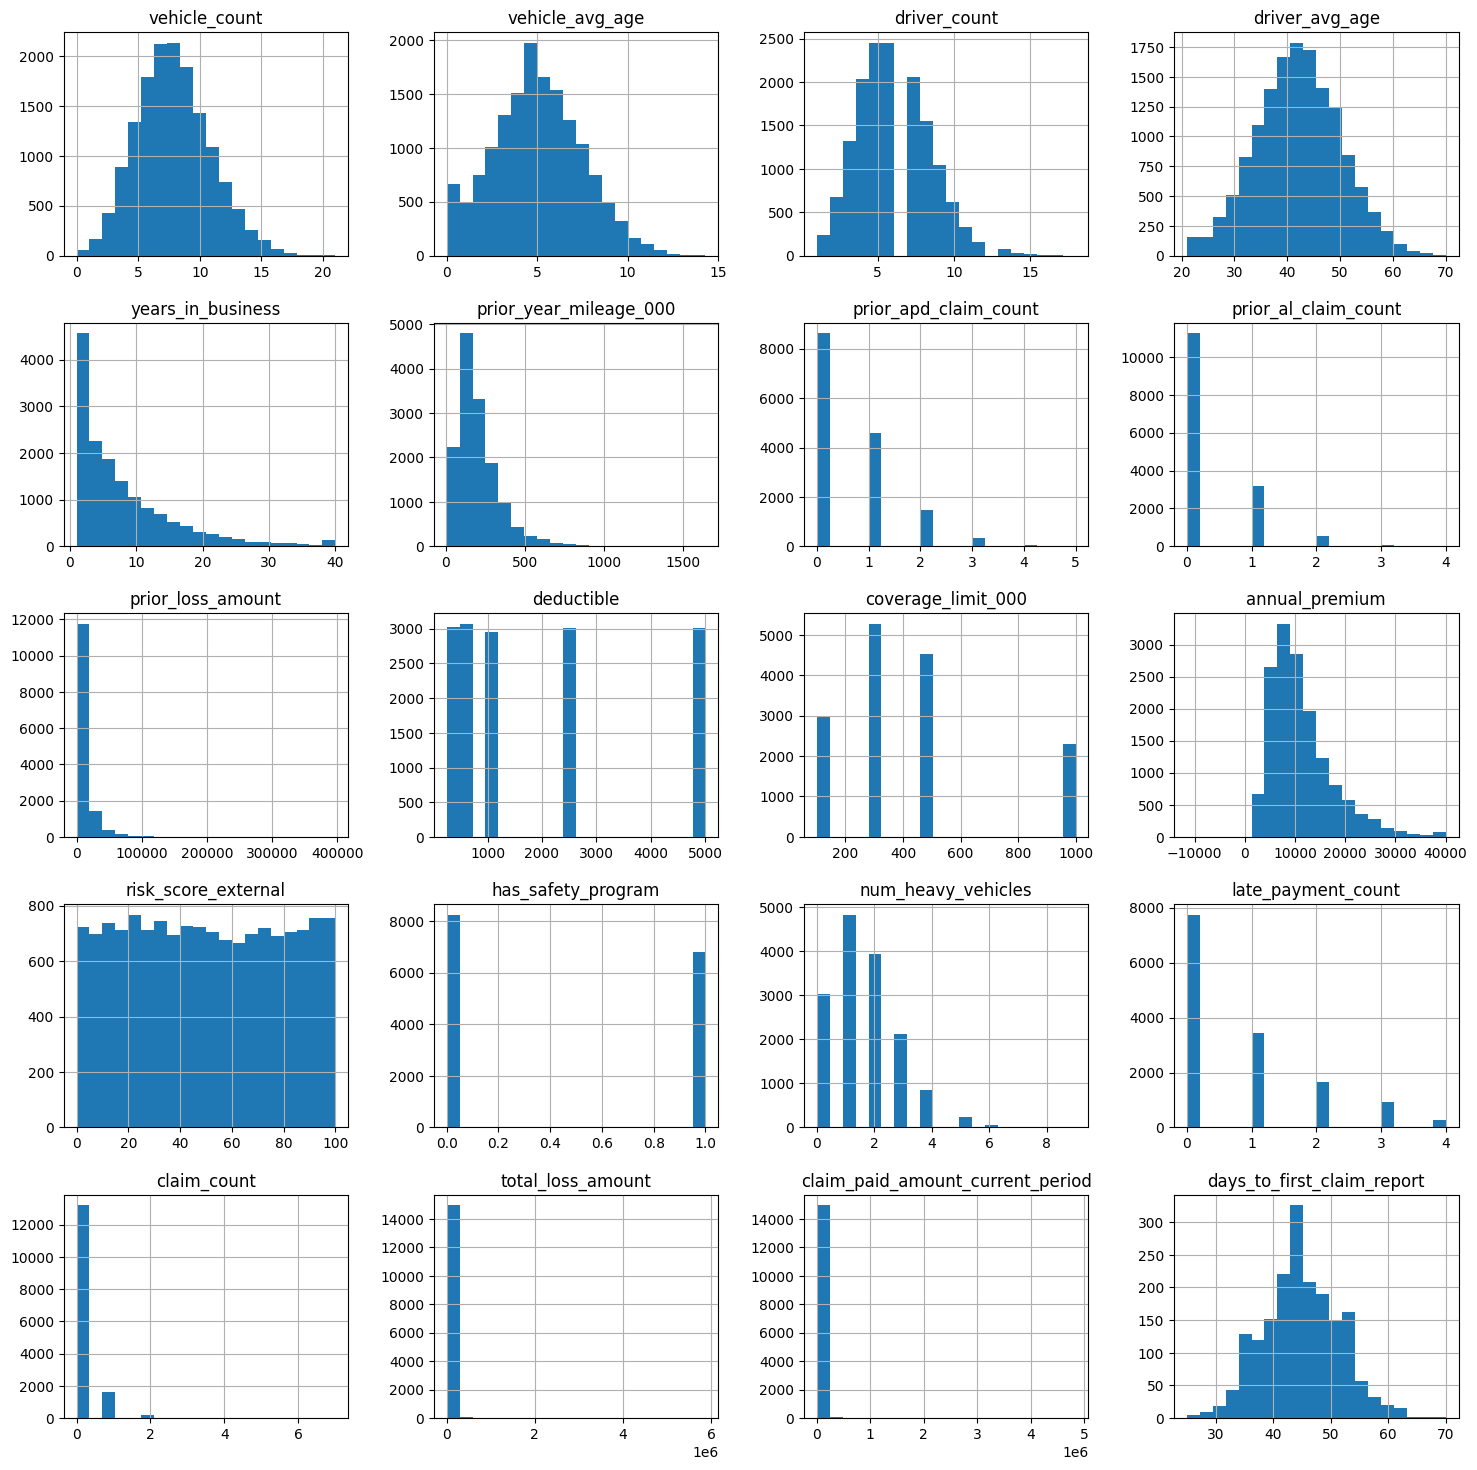

In [ ]:
df2.hist(figsize=(18, 18), bins=20)


In [ ]:
# ---- preprocessing ----

# fill numeric missing with 0 -- good enough for now
df2[df2.select_dtypes("number").columns] = df2.select_dtypes("number").fillna(0)
df3[df3.select_dtypes("number").columns] = df3.select_dtypes("number").fillna(0)

# encode categoricals for train
df2["coverage_type"] = df2["coverage_type"].astype("category").cat.codes
df2["business_type"]  = df2["business_type"].astype("category").cat.codes
df2["state"]          = df2["state"].astype("category").cat.codes

# same for score
df3["coverage_type"] = df3["coverage_type"].astype("category").cat.codes
df3["business_type"]  = df3["business_type"].astype("category").cat.codes
df3["state"]          = df3["state"].astype("category").cat.codes

In [ ]:
# ---- target ----
# using binary had-a-claim flag as target
df2["target"] = (df2["claim_count"] > 0).astype(int)
print("positive rate:", round(df2["target"].mean(), 3))

In [ ]:
# ---- features ----
feat_cols = [
    "coverage_type",
    "vehicle_count", "vehicle_avg_age", "driver_count", "driver_avg_age",
    "years_in_business", "prior_year_mileage_000",
    "business_type", "state",
    "prior_apd_claim_count", "prior_al_claim_count", "prior_loss_amount",
    "deductible", "coverage_limit_000", "annual_premium",
    "risk_score_external", "num_heavy_vehicles", "late_payment_count",
    "claim_paid_amount_current_period",
    "days_to_first_claim_report",
]

X = df2[feat_cols]
y = df2["target"]

In [ ]:
# ---- fit model ----

# random split -- not time-based
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tmp = LogisticRegression(max_iter=1000)
tmp.fit(X_train, y_train)

In [ ]:
# ---- evaluate ----
x1 = tmp.predict(X_train)
print("accuracy:", accuracy_score(y_train, x1))
# results look solid

In [ ]:
# ---- score new policies ----
X2 = df3[feat_cols]
preds = tmp.predict(X2)

df3["risk_score"] = preds
df3[["policy_id", "risk_score"]].to_csv("predictions.csv")
print("done -- predictions.csv written")